# Time Series Forecasting

## Import all libraries

In [1]:
import os
import torch
import seaborn as sns
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from darts import TimeSeries
from darts.metrics import(
    mape,
    mae, 
    mse 
)
from darts.utils.utils import(
    ModelMode,
    SeasonalityMode
)
from darts.models import(
    ARIMA,
    Prophet,
    ExponentialSmoothing,
)

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

/Users/deructu/amazinum/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## Load data

In [2]:
cwd = os.getcwd() # get current dir
path_to_csv = os.path.join(
    cwd, 
    'data', 
    'electricity_consumption_and_production.csv'
)
time_series = pd.read_csv(path_to_csv)

# 'DateTime' type is str, change him to datetime type, and set index
time_series = (time_series
               .assign(DateTime=lambda x: pd.to_datetime(x['DateTime']))
               .set_index('DateTime')
)

In [3]:
print(f'Size: {len(time_series)}')
time_series.head()

Size: 54161


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [4]:
# Checking nan 
time_series.isna().sum()

Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64

In [5]:
# Checking duplicates
time_series[time_series.index.duplicated()]

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-10-27 03:00:00,5196,4459,1373,74,725,719,1515,0,50
2019-10-27 03:00:00,5196,4459,1373,74,725,719,1515,0,50
2020-10-25 03:00:00,5220,5412,1418,1188,1098,594,1048,0,65
2020-10-25 03:00:00,5220,5412,1418,1188,1098,594,1048,0,65
2021-10-31 03:00:00,5341,5258,1415,141,934,1314,1393,0,58
2021-10-31 03:00:00,5341,5258,1415,141,934,1314,1393,0,58
2022-10-30 03:00:00,4503,5269,1384,544,1289,924,1073,0,52
2022-10-30 03:00:00,4503,5269,1384,544,1289,924,1073,0,52
2023-10-29 03:00:00,4607,4412,1376,221,1084,860,833,0,37


# Preprocessing

In [6]:
def preprocesing(df):
    '''Func for preprocessing time series'''
    
    time_series = df['Consumption']

    # Drop Duplicates
    time_series = time_series[~time_series.index.duplicated(keep='first')]

    # Daily range
    range = pd.date_range(start=time_series.index.min(), end=time_series.index.max(), freq='D')
    
    # Preprocess
    time_series = (time_series
                   .reindex(range)
                   .interpolate(method='linear')
                   .resample('D')
                   .mean()
                   .round(2)
    )

    return time_series

In [7]:
preprocessed_t_s = preprocesing(time_series)
print(f'Size: {len(preprocessed_t_s)}')
preprocessed_t_s.head()

Size: 2270


2019-01-01    6352.0
2019-01-02    5647.0
2019-01-03    5918.0
2019-01-04    6610.0
2019-01-05    6720.0
Freq: D, Name: Consumption, dtype: float64

## EDA

#### Time Series

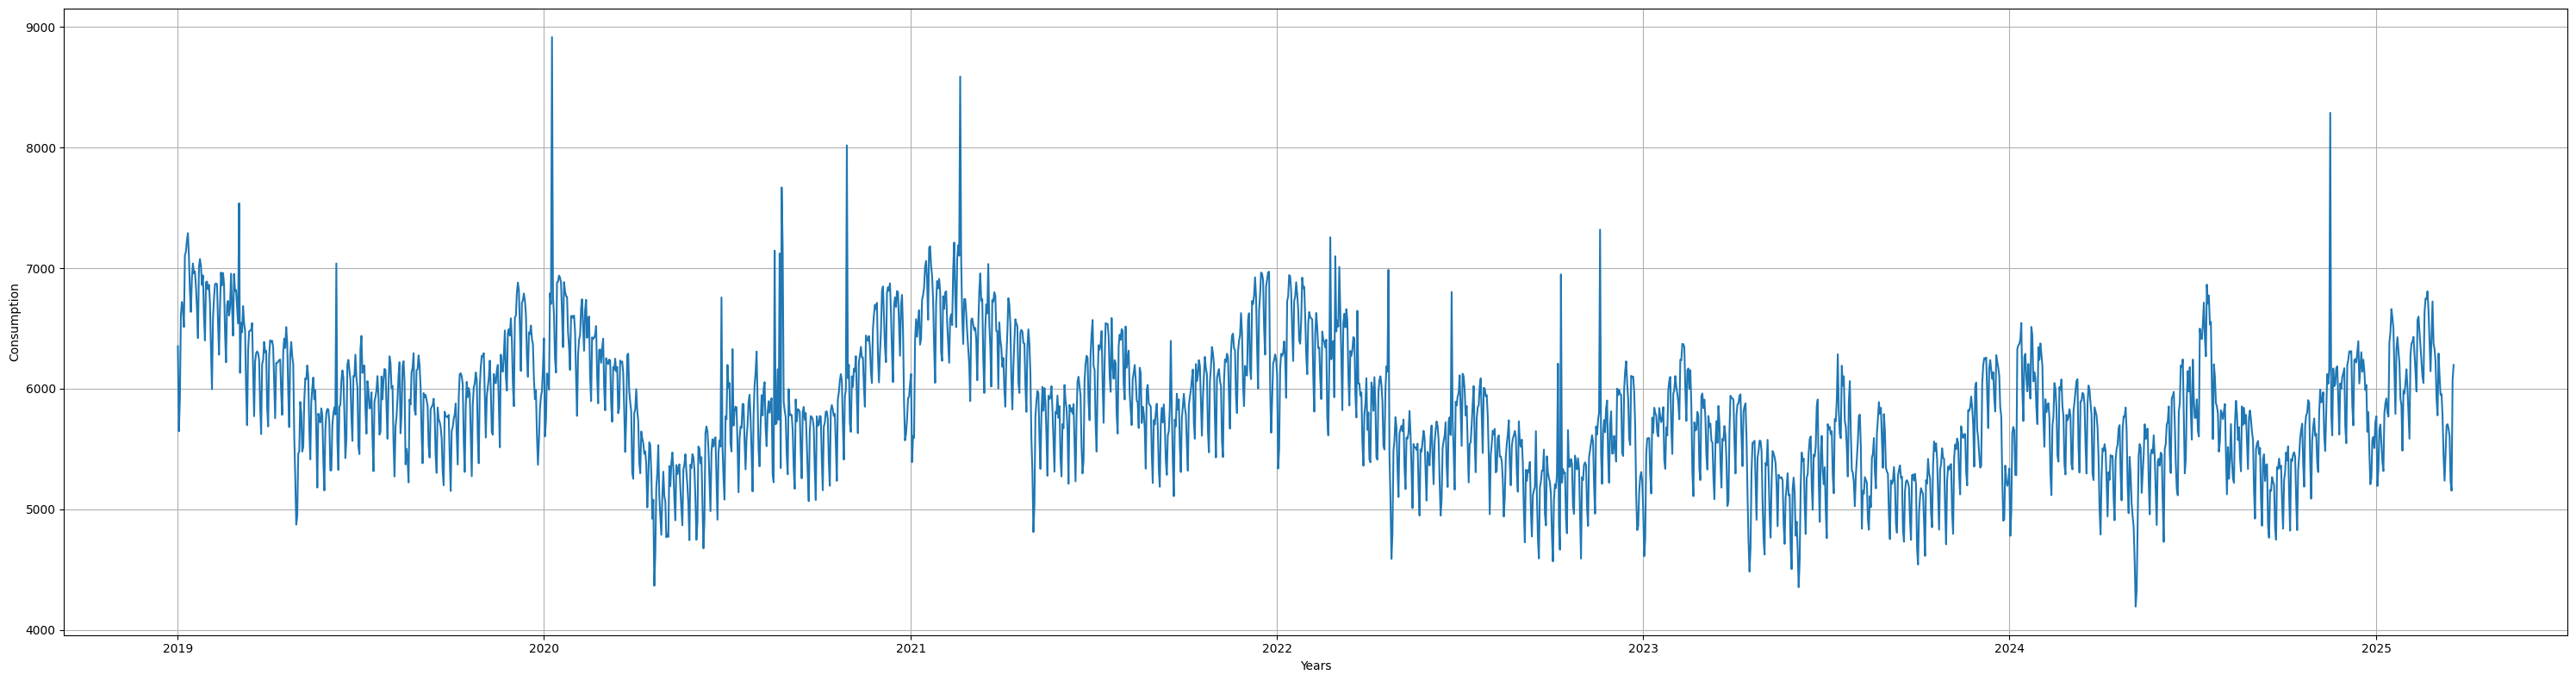

In [8]:
# Plot Time Series
plt.figure(figsize=(30, 8))

plt.plot(preprocessed_t_s.index, preprocessed_t_s)
plt.xlabel('Years')
plt.ylabel('Consumption')
plt.grid()

plt.tight_layout()

#### Seasonal Decomposition

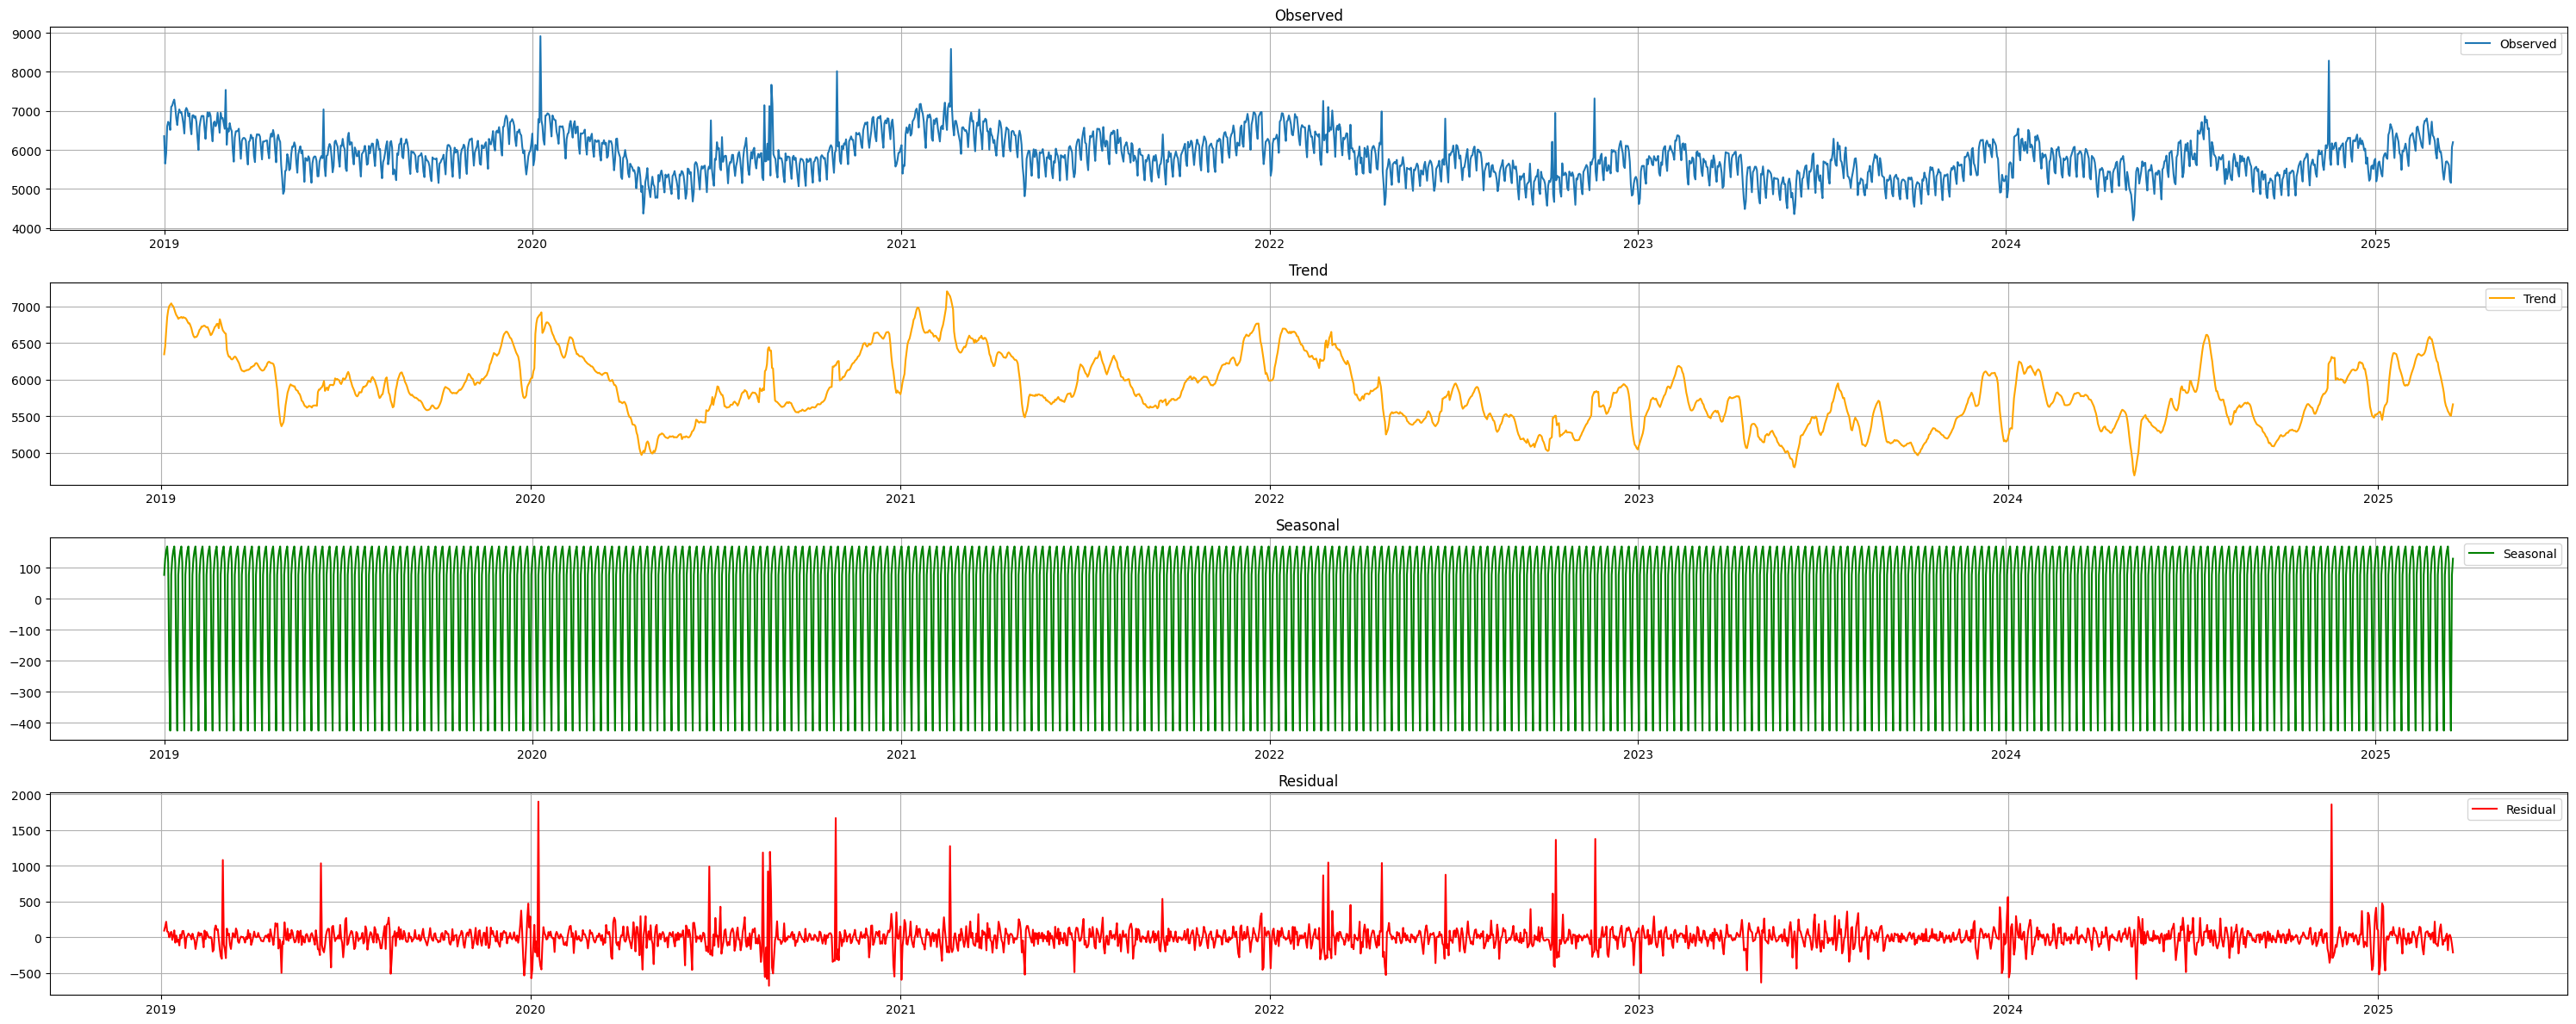

In [9]:
decomp = seasonal_decompose(preprocessed_t_s, model='additive', period=7) # Season deomposition

fig, axs = plt.subplots(4, 1, figsize=(30, 12))

axs[0].plot(preprocessed_t_s.index, preprocessed_t_s, label='Observed')
axs[0].set_title('Observed')
axs[0].legend()
axs[0].grid()

axs[1].plot(decomp.trend, label='Trend', color='orange')
axs[1].set_title('Trend')
axs[1].legend()
axs[1].grid()

axs[2].plot(decomp.seasonal, label='Seasonal', color='green')
axs[2].set_title('Seasonal')
axs[2].legend()
axs[2].grid()

axs[3].plot(decomp.resid, label='Residual', color='red')
axs[3].set_title('Residual')
axs[3].legend()
axs[3].grid()

fig.tight_layout()

#### ACF and PACF

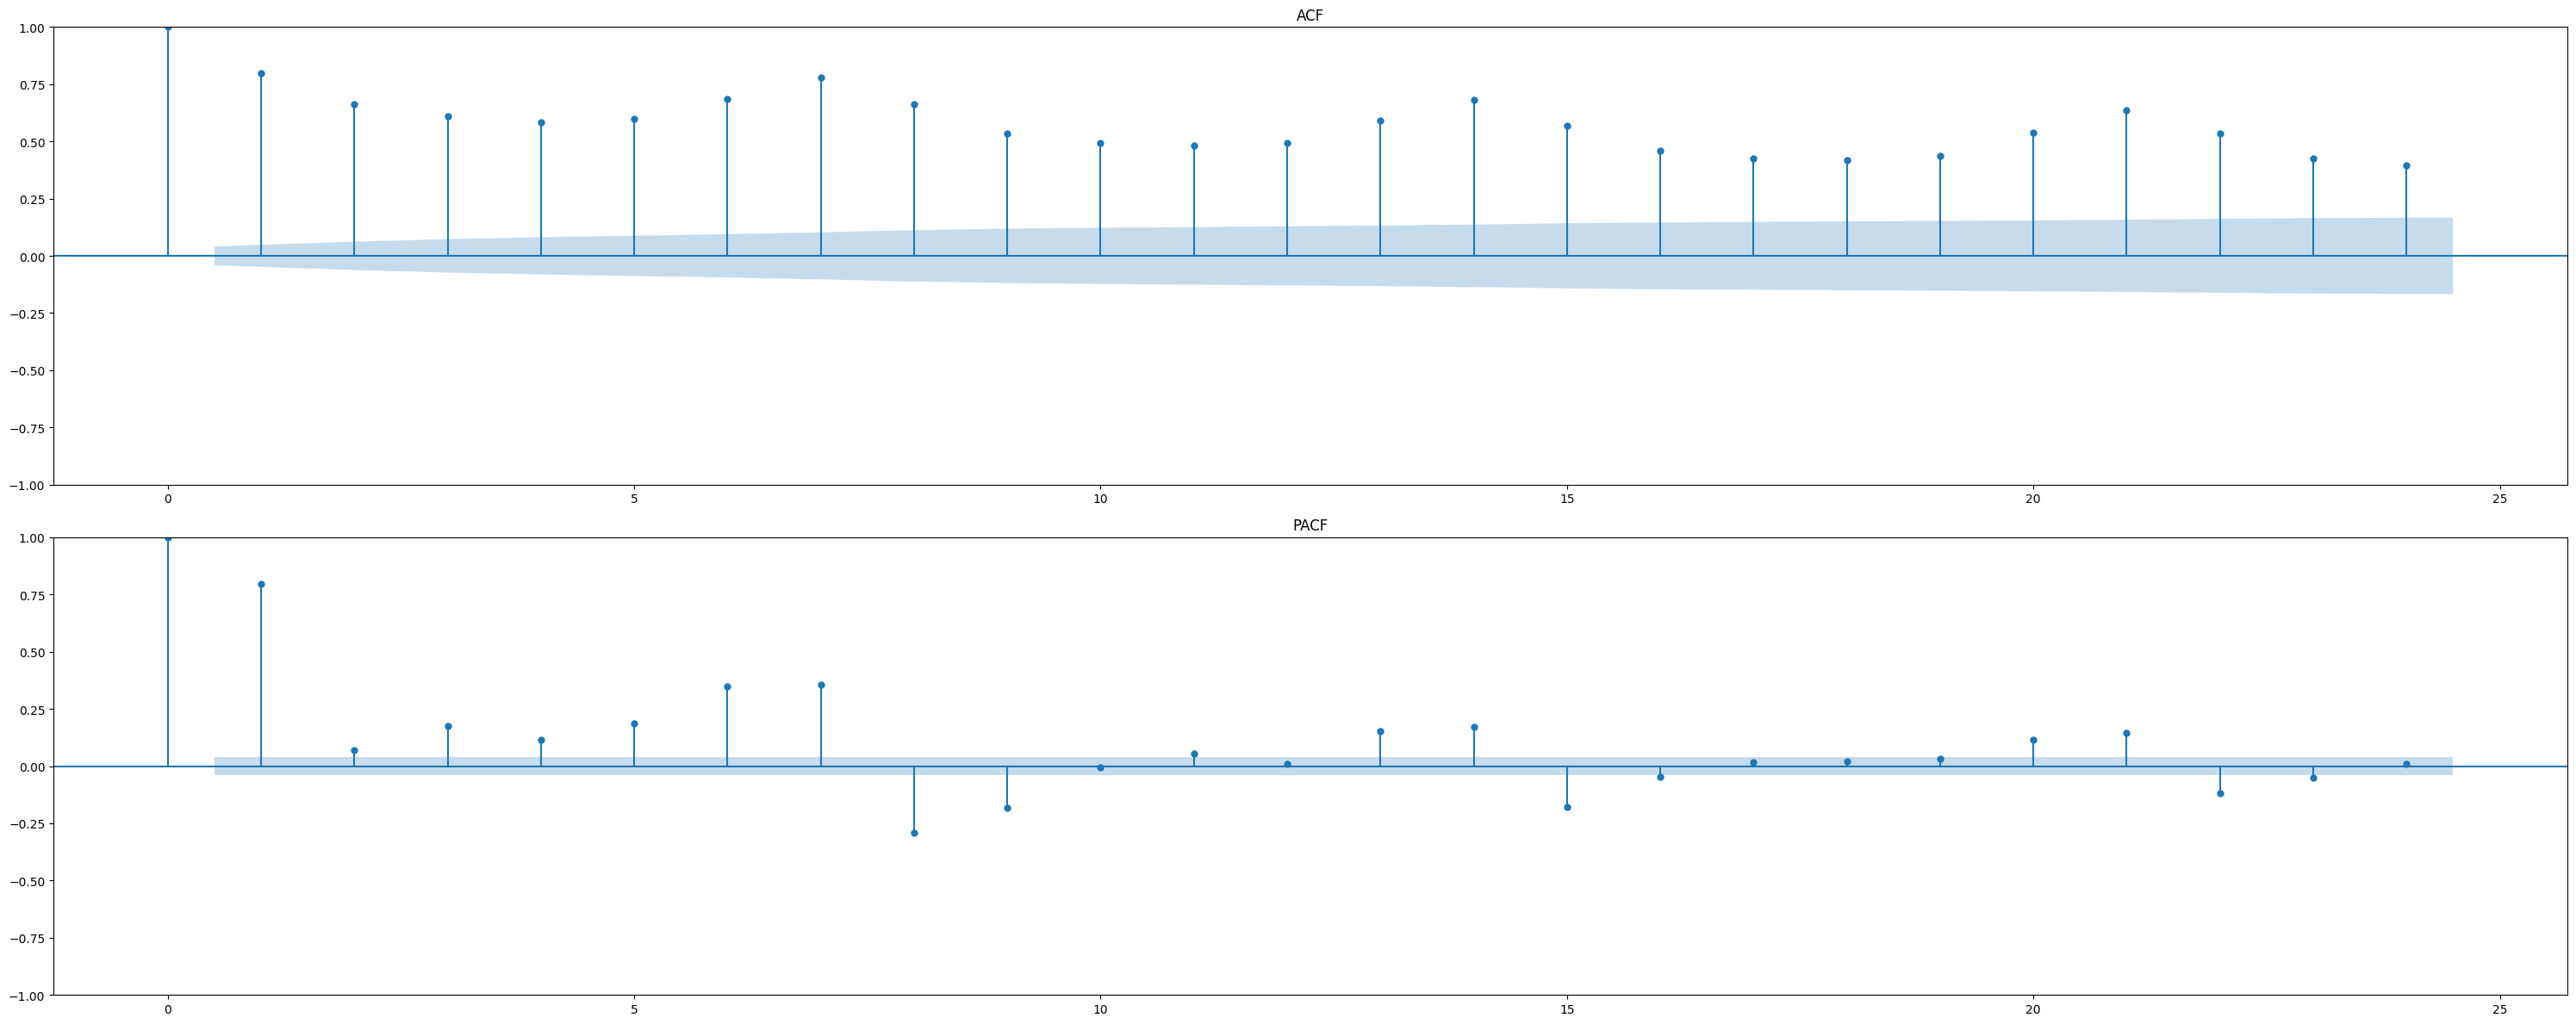

In [10]:
fig, axs = plt.subplots(2, 1, figsize=(30, 12))

plot_acf(preprocessed_t_s, lags=24, ax=axs[0], title='ACF')
plot_pacf(preprocessed_t_s, lags=24, ax=axs[1], title='PACF')
fig.tight_layout()

# ADF test

In [11]:
def adf_stationarity_test(series: pd.Series):
    ''' Func for ADF testing'''
    
    result = adfuller(series)
    p_value = result[1]
    return p_value

p_value = adf_stationarity_test(preprocessed_t_s)

print(f'P-Value: {p_value.round(3)}\nStationary: {p_value < 0.05}')

P-Value: 0.011
Stationary: True


## Build  Models

In [12]:
ts = TimeSeries.from_series(preprocessed_t_s, freq='D')

#### ARIMA model


In [13]:
def arima_model(predict_days):
    ''' Training SARIMA model '''
    train_set = ts[:-predict_days]
    test_set = ts[-predict_days:]
    

    best_model = ARIMA(1, 1, 1, (1, 1, 1, 7))
    best_model.fit(train_set)
    preds = best_model.predict(n=len(test_set))

    return train_set, test_set, preds

dict_metricts = dict()

def metrics(test_set, preds):
    '''Func for compute metrics'''
    print(f'MAPE: {mape(test_set, preds)}')
    print(f'MSE: {mse(test_set, preds)}')
    print(f'MAE: {mae(test_set, preds)}')
    print()


def plot_results(train_set, test_set, preds, title, ax):
    train_set = train_set.to_series()
    test_set = test_set.to_series()
    preds_set = preds.to_series()

    ax.plot(train_set.index, train_set.values, label='Train')
    ax.plot(test_set.index, test_set.values, label='Test')
    ax.plot(preds_set.index, preds_set.values, label='Forecast')

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    ax.set_title(title + f'  Forecasted days: {len(test_set)}')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(alpha=0.3)

Metrics for 15 days
MAPE: 9.514286610859084
MSE: 321510.0532838363
MAE: 530.4991012216358


Metrics for 30 days
MAPE: 7.645276213786011
MSE: 276829.1246185113
MAE: 440.2750040011487


Metrics for 45 days
MAPE: 5.856824515001857
MSE: 162149.07904302725
MAE: 359.4649747556612




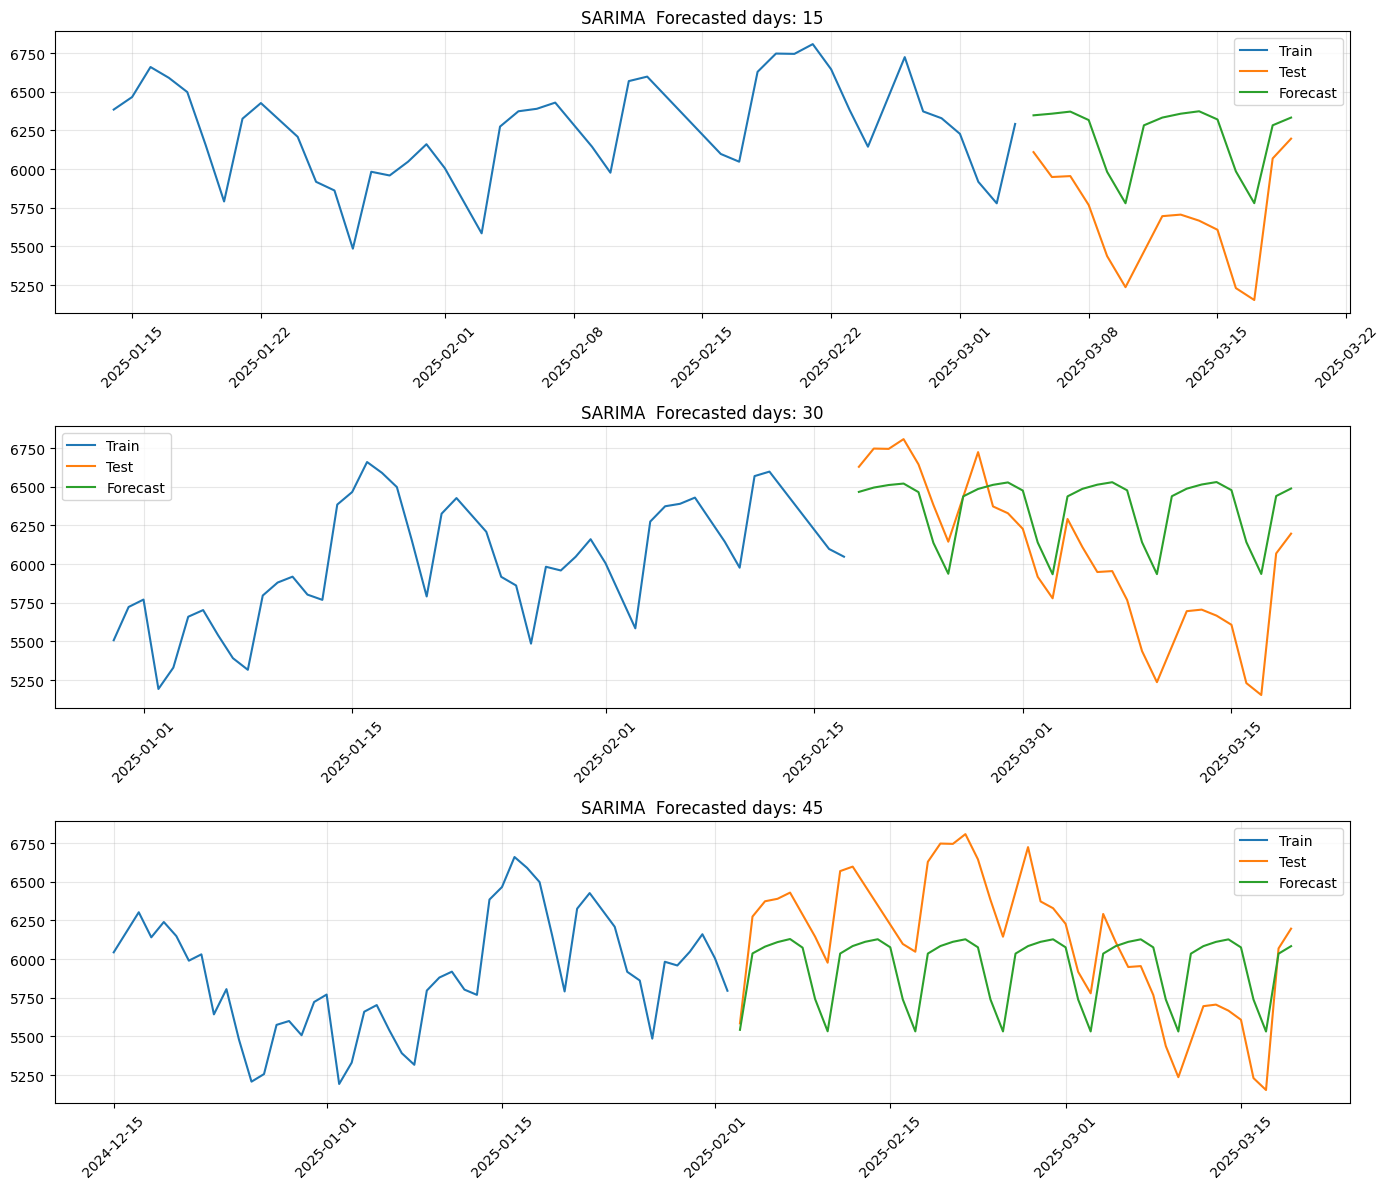

In [14]:
DAYS = [15, 30, 45]

fig, axs = plt.subplots(len(DAYS), 1, figsize=(14, 12), sharex=False)
for d, ax in zip(DAYS, axs):
    train_set, test_set, preds = arima_model(d)
    plot_results(train_set[-50:], test_set, preds, 'SARIMA', ax)
    print(f'Metrics for {d} days')
    metrics(test_set, preds)
    print()
plt.tight_layout()



#### Prophet model

In [15]:
def prophet_model_optuna(predict_days, n_trials=20):
    ''' Training and fitting Prophet model'''
    train_set = ts[:-predict_days]
    test_set = ts[-predict_days:]

    def objective(trial):
        changepoint_prior_scale = trial.suggest_float("changepoint_prior_scale", 0.001, 0.5, log=True)
        seasonality_mode = trial.suggest_categorical("seasonality_mode", ["additive", "multiplicative"])
        yearly_seasonality = trial.suggest_categorical("yearly_seasonality", [True, False])
        weekly_seasonality = trial.suggest_categorical("weekly_seasonality", [True, False])

        model = Prophet(
            changepoint_prior_scale=changepoint_prior_scale,
            seasonality_mode=seasonality_mode,
            yearly_seasonality=yearly_seasonality,
            weekly_seasonality=weekly_seasonality
        )

        model.fit(train_set)
        preds = model.predict(n=len(test_set))

        return mape(test_set, preds)

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params

    best_model = Prophet(**best_params)
    best_model.fit(train_set)
    preds = best_model.predict(n=len(test_set))

    return train_set, test_set, preds

[I 2026-05-15 21:08:15,224] A new study created in memory with name: no-name-b24b6ac9-5c28-48e9-99f0-42d3e54ba509
21:08:15 - cmdstanpy - INFO - Chain [1] start processing
21:08:15 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-05-15 21:08:15,487] Trial 0 finished with value: 6.519225991795792 and parameters: {'changepoint_prior_scale': 0.010253509690168486, 'seasonality_mode': 'additive', 'yearly_seasonality': True, 'weekly_seasonality': True}. Best is trial 0 with value: 6.519225991795792.
21:08:15 - cmdstanpy - INFO - Chain [1] start processing
21:08:15 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-05-15 21:08:15,815] Trial 1 finished with value: 5.048558931569523 and parameters: {'changepoint_prior_scale': 0.21766241123453678, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': False, 'weekly_seasonality': True}. Best is trial 1 with value: 5.048558931569523.
21:08:15 - cmdstanpy - INFO - Chain [1] start processing
21:08:15 - cmdstanpy - INFO - Chain [1] don

Metrics for 15 days
MAPE: 3.107609345099616
MSE: 46947.52203806957
MAE: 178.50661034976673




21:08:19 - cmdstanpy - INFO - Chain [1] start processing
21:08:19 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-05-15 21:08:19,356] Trial 1 finished with value: 6.509387912396819 and parameters: {'changepoint_prior_scale': 0.21766241123453678, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': False, 'weekly_seasonality': True}. Best is trial 0 with value: 4.938487717994816.
21:08:19 - cmdstanpy - INFO - Chain [1] start processing
21:08:19 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-05-15 21:08:19,459] Trial 2 finished with value: 5.850899335848152 and parameters: {'changepoint_prior_scale': 0.003095566460242371, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': True, 'weekly_seasonality': False}. Best is trial 0 with value: 4.938487717994816.
21:08:19 - cmdstanpy - INFO - Chain [1] start processing
21:08:19 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-05-15 21:08:19,521] Trial 3 finished with value: 9.485876687388865 and parameters: {'c

Metrics for 30 days
MAPE: 4.8943249473404835
MSE: 110290.42583349772
MAE: 292.6962027286829




21:08:22 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-05-15 21:08:22,689] Trial 0 finished with value: 4.3195929811663145 and parameters: {'changepoint_prior_scale': 0.010253509690168486, 'seasonality_mode': 'additive', 'yearly_seasonality': True, 'weekly_seasonality': True}. Best is trial 0 with value: 4.3195929811663145.
21:08:22 - cmdstanpy - INFO - Chain [1] start processing
21:08:22 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-05-15 21:08:22,952] Trial 1 finished with value: 6.9733459001528875 and parameters: {'changepoint_prior_scale': 0.21766241123453678, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': False, 'weekly_seasonality': True}. Best is trial 0 with value: 4.3195929811663145.
21:08:22 - cmdstanpy - INFO - Chain [1] start processing
21:08:23 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-05-15 21:08:23,066] Trial 2 finished with value: 6.257063546248862 and parameters: {'changepoint_prior_scale': 0.003095566460242371, 'seasonality_

Metrics for 45 days
MAPE: 4.30724484048103
MSE: 93119.91760091159
MAE: 260.12052763927016




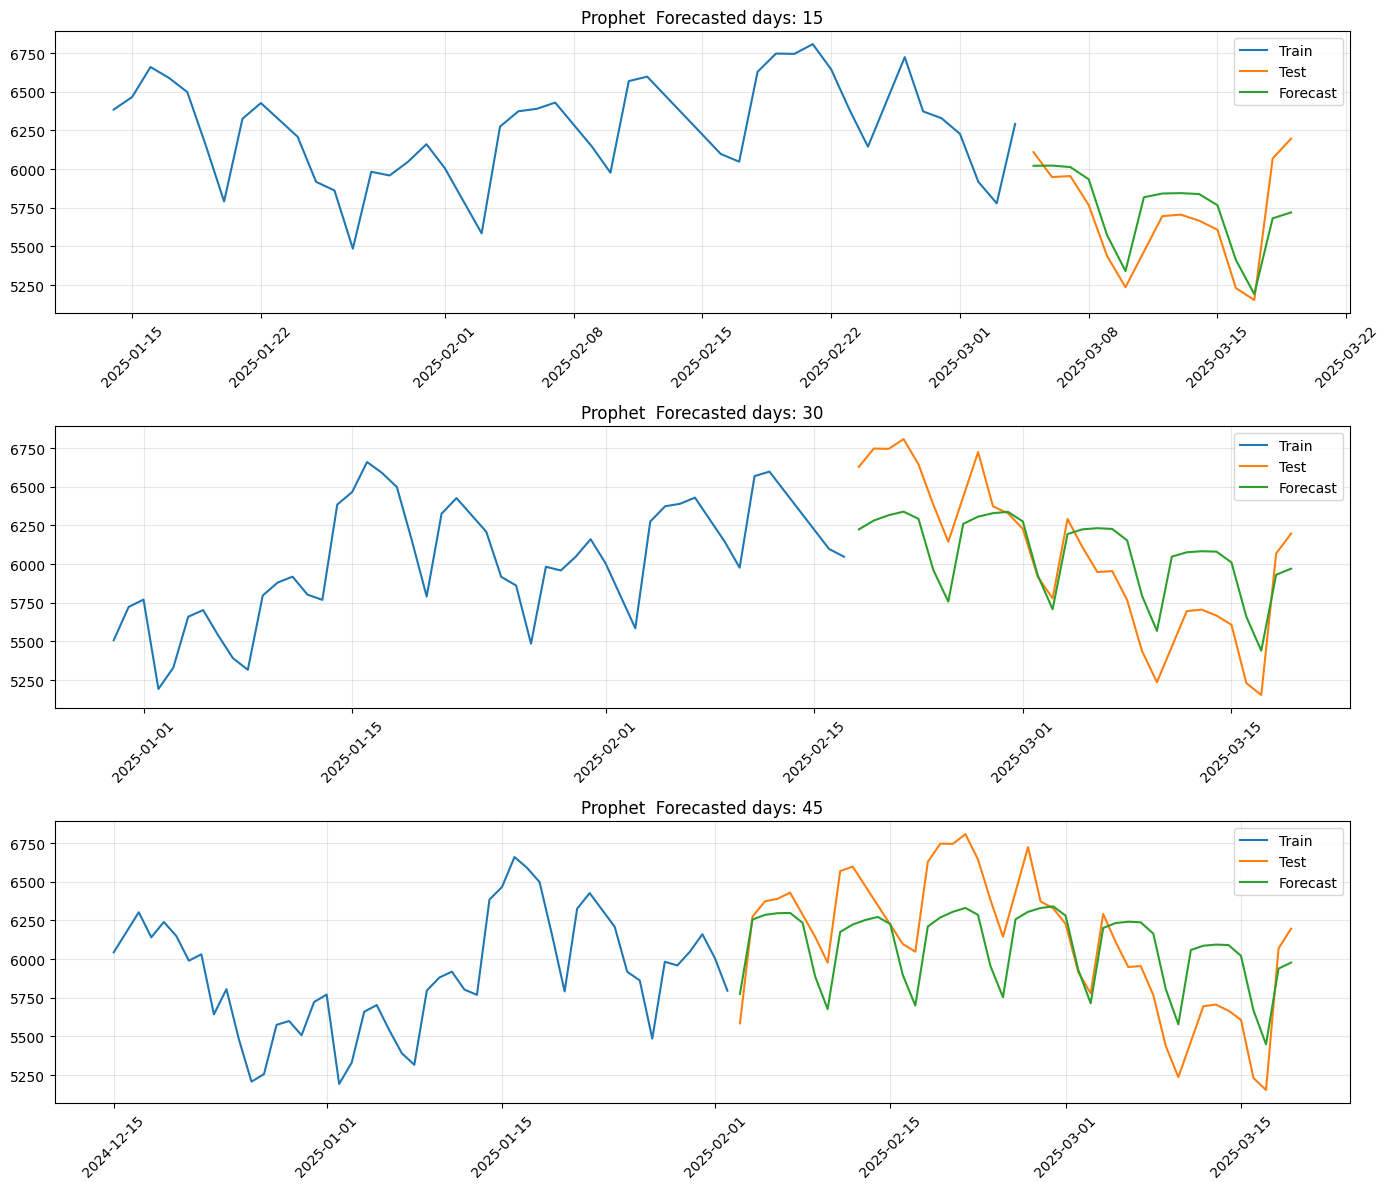

In [16]:
fig, axs = plt.subplots(len(DAYS), 1, figsize=(14, 12), sharex=False)
for d, ax in zip(DAYS, axs):
    train_set, test_set, preds = prophet_model_optuna(d)
    plot_results(train_set[-50:], test_set, preds, 'Prophet', ax)
    print(f'Metrics for {d} days')
    metrics(test_set, preds)
    print()
plt.tight_layout()

#### Exponential Smoothing (Holt-Winters)

In [17]:
def ex_model(predict_days, n_trials=20):
    train_set = ts[:-predict_days]
    test_set = ts[-predict_days:]

    TREND_MAP    = {"additive": ModelMode.ADDITIVE, "multiplicative": ModelMode.MULTIPLICATIVE, "none": ModelMode.NONE}
    SEASONAL_MAP = {"additive": SeasonalityMode.ADDITIVE, "multiplicative": SeasonalityMode.MULTIPLICATIVE}

    def objective(trial):
        trend_str = trial.suggest_categorical('trend', ['addivite', 'multiplicative', 'none'])
        seasonal = trial.suggest_categorical('seasonal', ['addivite', 'multiplicative'])
        damped = trial.suggest_categorical('damped', [True, False])

        if trend_str == 'none' and damped:
            return float('inf')
        try:
            model = ExponentialSmoothing(
                trend=TREND_MAP[trend_str],
                seasonal=SEASONAL_MAP[seasonal],
                damped=damped,
                seasonal_periods=7
            )
            model.fit(train_set)
            preds = model.predict(n=len(test_set))
            return mape(test_set, preds)
        except Exception:
            return float('inf')
        
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)

    bp= study.best_params

    best_model = ExponentialSmoothing(
        trend=TREND_MAP[bp["trend"]], seasonal=SEASONAL_MAP[bp["seasonal"]],
        damped=bp["damped"], seasonal_periods=7,
    )
    best_model.fit(train_set)
    preds = best_model.predict(n=len(test_set))

    return train_set, test_set, preds

[I 2026-05-15 21:08:26,703] A new study created in memory with name: no-name-9585d675-2d93-4af8-9014-5aa35cf2ad00
[I 2026-05-15 21:08:26,704] Trial 0 finished with value: inf and parameters: {'trend': 'multiplicative', 'seasonal': 'addivite', 'damped': True}. Best is trial 0 with value: inf.
[I 2026-05-15 21:08:26,704] Trial 1 finished with value: inf and parameters: {'trend': 'addivite', 'seasonal': 'multiplicative', 'damped': True}. Best is trial 0 with value: inf.
[I 2026-05-15 21:08:26,704] Trial 2 finished with value: inf and parameters: {'trend': 'none', 'seasonal': 'addivite', 'damped': False}. Best is trial 0 with value: inf.
[I 2026-05-15 21:08:26,731] Trial 3 finished with value: 9.457137449585026 and parameters: {'trend': 'none', 'seasonal': 'multiplicative', 'damped': False}. Best is trial 3 with value: 9.457137449585026.
[I 2026-05-15 21:08:26,732] Trial 4 finished with value: inf and parameters: {'trend': 'none', 'seasonal': 'addivite', 'damped': False}. Best is trial 3 w

Metrics for 15 days
MAPE: 9.273152545522963
MSE: 307254.42160664644
MAE: 517.3503002957808




[I 2026-05-15 21:08:36,406] Trial 8 finished with value: 7.700579034688408 and parameters: {'trend': 'multiplicative', 'seasonal': 'multiplicative', 'damped': False}. Best is trial 8 with value: 7.700579034688408.
[I 2026-05-15 21:08:36,433] Trial 9 finished with value: 7.96282972328875 and parameters: {'trend': 'none', 'seasonal': 'multiplicative', 'damped': False}. Best is trial 8 with value: 7.700579034688408.
[I 2026-05-15 21:08:37,312] Trial 10 finished with value: 7.94636791026269 and parameters: {'trend': 'multiplicative', 'seasonal': 'multiplicative', 'damped': True}. Best is trial 8 with value: 7.700579034688408.
[I 2026-05-15 21:08:38,192] Trial 11 finished with value: 7.94636791026269 and parameters: {'trend': 'multiplicative', 'seasonal': 'multiplicative', 'damped': True}. Best is trial 8 with value: 7.700579034688408.
[I 2026-05-15 21:08:39,063] Trial 12 finished with value: 7.94636791026269 and parameters: {'trend': 'multiplicative', 'seasonal': 'multiplicative', 'damped'

Metrics for 30 days
MAPE: 7.700579034688408
MSE: 282197.73704098404
MAE: 443.1490426859552




[I 2026-05-15 21:08:45,220] Trial 8 finished with value: 5.819131683858853 and parameters: {'trend': 'multiplicative', 'seasonal': 'multiplicative', 'damped': False}. Best is trial 3 with value: 5.776245068197228.
[I 2026-05-15 21:08:45,250] Trial 9 finished with value: 5.776245068197228 and parameters: {'trend': 'none', 'seasonal': 'multiplicative', 'damped': False}. Best is trial 3 with value: 5.776245068197228.
[I 2026-05-15 21:08:45,251] Trial 10 finished with value: inf and parameters: {'trend': 'none', 'seasonal': 'multiplicative', 'damped': True}. Best is trial 3 with value: 5.776245068197228.
[I 2026-05-15 21:08:45,281] Trial 11 finished with value: 5.776245068197228 and parameters: {'trend': 'none', 'seasonal': 'multiplicative', 'damped': False}. Best is trial 3 with value: 5.776245068197228.
[I 2026-05-15 21:08:45,311] Trial 12 finished with value: 5.776245068197228 and parameters: {'trend': 'none', 'seasonal': 'multiplicative', 'damped': False}. Best is trial 3 with value: 5

Metrics for 45 days
MAPE: 5.776245068197228
MSE: 158410.5123916587
MAE: 353.893882189946




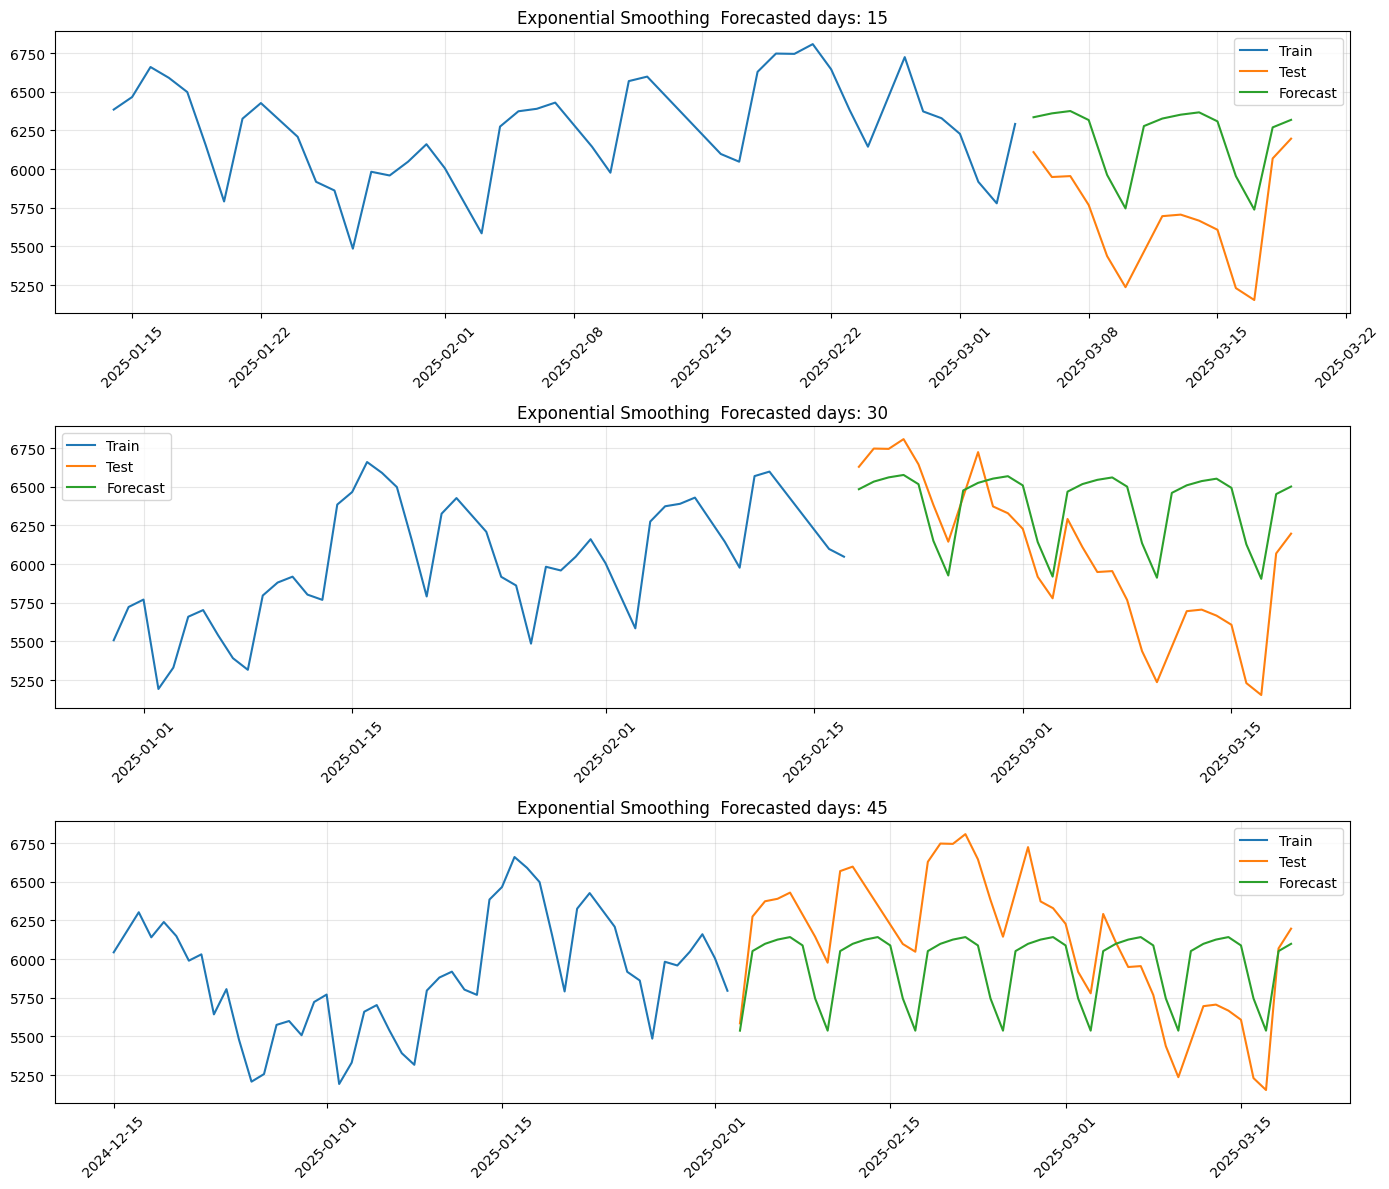

In [18]:
DAYS = [15, 30, 45]

fig, axs = plt.subplots(len(DAYS), 1, figsize=(14, 12), sharex=False)
for d, ax in zip(DAYS, axs):
    train_set, test_set, preds = ex_model(d)
    plot_results(train_set[-50:], test_set, preds, 'Exponential Smoothing', ax)
    print(f'Metrics for {d} days')
    metrics(test_set, preds)
    print()
plt.tight_layout()

#### Chronos

In [19]:
from chronos import BaseChronosPipeline

chronos_pipe = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-base",
    device_map="cpu",
    torch_dtype=torch.bfloat16,
)

from darts import TimeSeries

def chronos_model(predict_days):
    ''' Func for trainig Chronos Model'''
    train_series = ts[:-predict_days]
    test_series = ts[-predict_days:]

    context = torch.tensor(
        train_series.univariate_values(),
        dtype=torch.float32
    )

    quantiles, mean = chronos_pipe.predict_quantiles(
        inputs=context,
        prediction_length=len(test_series),
        quantile_levels=[0.1, 0.5, 0.9],
    )

    preds = TimeSeries.from_times_and_values(
        times=test_series.time_index,
        values=mean[0]
    )

    return train_series, test_series, preds

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


Metrics for 15 days
MAPE: 10.393181498897258
MSE: 376724.61666666664
MAE: 580.0333333333333


Metrics for 30 days
MAPE: 6.048747185006326
MSE: 165270.41666666666
MAE: 354.6666666666667


Metrics for 45 days
MAPE: 6.292231206801351
MSE: 193352.97222222222
MAE: 390.3222222222222




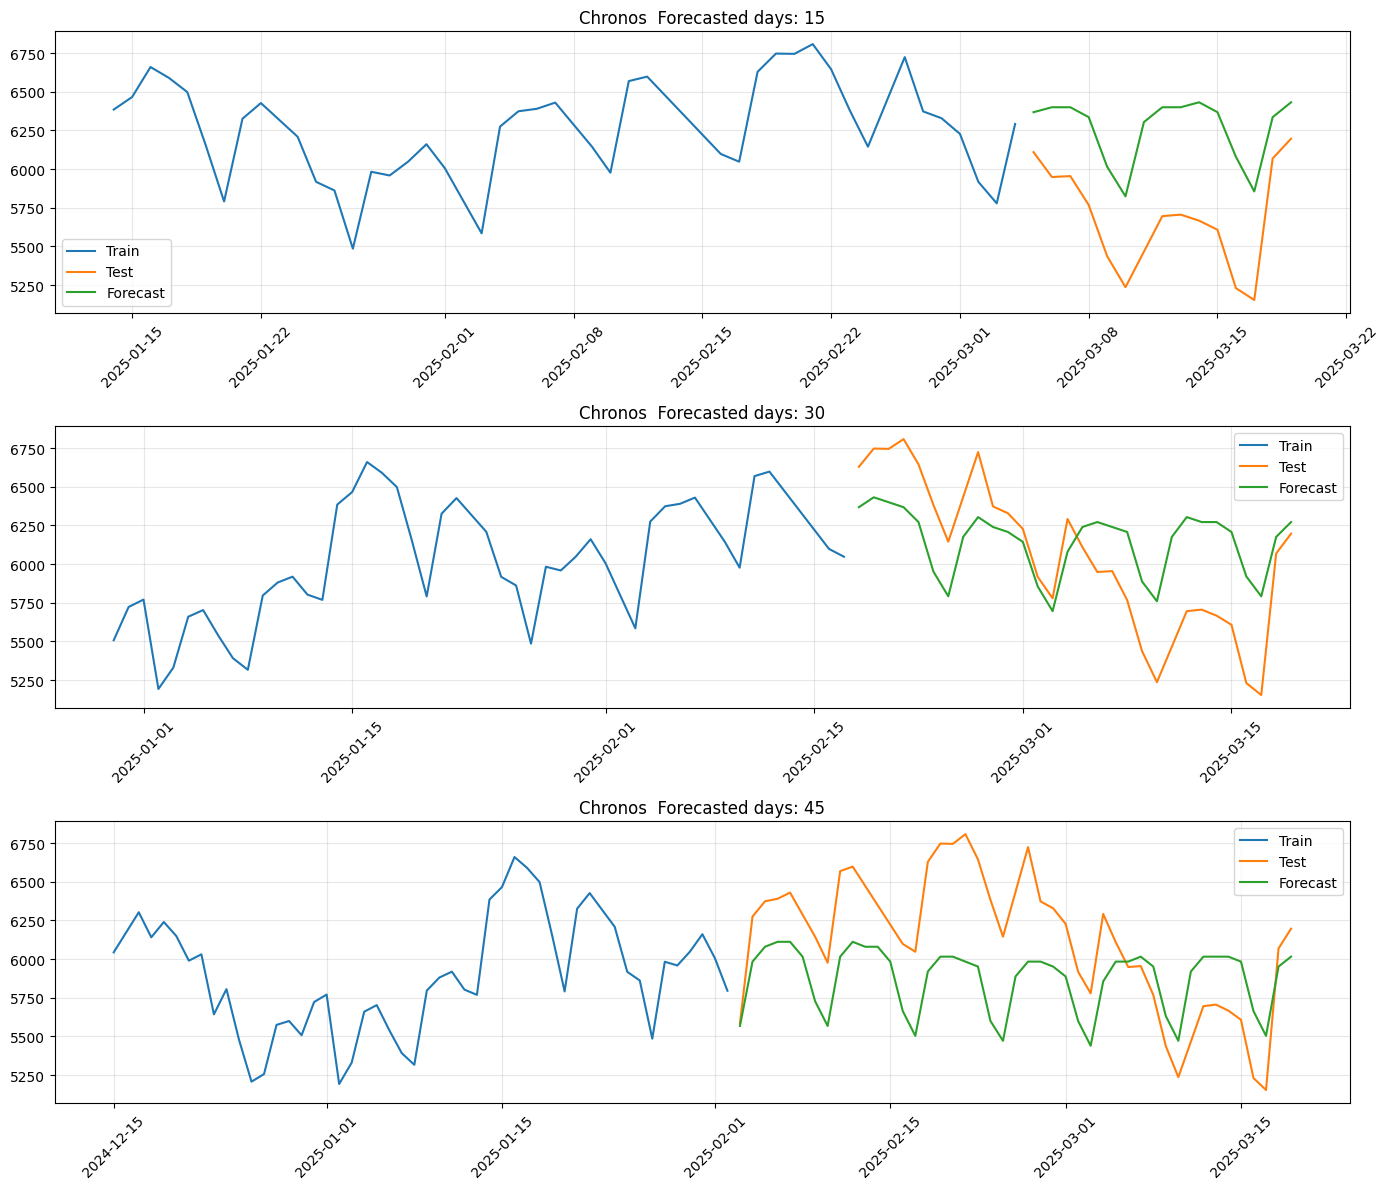

In [20]:
DAYS = [15, 30, 45]

fig, axs = plt.subplots(len(DAYS), 1, figsize=(14, 12), sharex=False)
for d, ax in zip(DAYS, axs):
    train_set, test_set, preds = chronos_model(d)
    plot_results(train_set[-50:], test_set, preds, 'Chronos', ax)
    print(f'Metrics for {d} days')
    metrics(test_set, preds)
    print()
plt.tight_layout()